# 01 - The Met API Pilot Review

Este notebook revisa la primera extracción piloto de textiles andinos desde The Metropolitan Museum of Art Collection API.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

In [2]:
metadata_path = Path("../data/processed/met_textiles_pilot.csv")

df = pd.read_csv(metadata_path)

print("Registros:", len(df))
df.head()

Registros: 146


,source,institution,object_id,title,culture,period,object_date,country,region,subregion,...,repository,object_url,primary_image,primary_image_small,is_public_domain,rights_and_reproduction,artist_display_name,artist_culture,tags,query_term
0,met,The Metropolitan Museum of Art,675980,Tunic,Wari,NaN,650–1000 CE,NaN,Andean region,NaN,...,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,https://images.metmuseum.org/CRDImages/ao/orig...,https://images.metmuseum.org/CRDImages/ao/web-...,True,NaN,Wari artist,NaN,NaN,Andean textile
1,met,The Metropolitan Museum of Art,320054,Miniature tabard,Inca and Spanish,NaN,1600–1700,Bolivia or Peru,NaN,NaN,...,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,https://images.metmuseum.org/CRDImages/ao/orig...,https://images.metmuseum.org/CRDImages/ao/web-...,True,NaN,NaN,NaN,NaN,Andean textile
2,met,The Metropolitan Museum of Art,313153,Tunic with Felines,Chimú,NaN,1450–1550,Peru,NaN,NaN,...,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,https://images.metmuseum.org/CRDImages/ao/orig...,https://images.metmuseum.org/CRDImages/ao/web-...,True,NaN,NaN,NaN,Cats,Andean textile
3,met,The Metropolitan Museum of Art,307991,Tunic fragment,Wari,NaN,650–1000 CE,Peru,NaN,NaN,...,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,https://images.metmuseum.org/CRDImages/ao/orig...,https://images.metmuseum.org/CRDImages/ao/web-...,True,NaN,Wari artist,NaN,NaN,Andean textile
4,met,The Metropolitan Museum of Art,307977,Feathered Tunic,Chimú,NaN,1200 – 1400 CE,Peru,NaN,NaN,...,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,https://images.metmuseum.org/CRDImages/ao/orig...,https://images.metmuseum.org/CRDImages/ao/web-...,True,NaN,Chimú artist(s),NaN,NaN,Andean textile


In [3]:
df.columns.tolist()

['source',
 'institution',
 'object_id',
 'title',
 'culture',
 'period',
 'object_date',
 'country',
 'region',
 'subregion',
 'locale',
 'classification',
 'department',
 'medium',
 'dimensions',
 'credit_line',
 'repository',
 'object_url',
 'primary_image',
 'primary_image_small',
 'is_public_domain',
 'rights_and_reproduction',
 'artist_display_name',
 'artist_culture',
 'tags',
 'query_term']

In [4]:
quality_summary = pd.DataFrame({
    "column": df.columns,
    "non_null": [df[col].notna().sum() for col in df.columns],
    "nulls": [df[col].isna().sum() for col in df.columns],
    "unique_values": [df[col].nunique() for col in df.columns],
})

quality_summary.sort_values("non_null", ascending=False)

,column,non_null,nulls,unique_values
0,source,146,0,1
1,institution,146,0,1
2,object_id,146,0,146
3,title,146,0,75
15,credit_line,146,0,38
16,repository,146,0,1
14,dimensions,146,0,141
13,medium,146,0,36
12,department,146,0,2
11,classification,146,0,15


In [5]:
df["culture"].value_counts(dropna=False).head(20)

culture
Peruvian                 35
Inca                     28
Paracas                  25
Wari                     18
Nasca                    13
Chimú                     4
Inca (?)                  4
Moche                     3
Chancay                   3
Tiwanaku                  2
NaN                       2
Inca and Spanish          1
Nasca-Wari                1
Chuquibamba               1
Chavín                    1
Tiwanaku or Wari          1
Lambayeque (Sicán)        1
Cupisnique                1
Wari or Inca              1
Peru; south coast (?)     1
Name: count, dtype: int64

In [6]:
df["classification"].value_counts(dropna=False).head(20)

classification
Textiles-Woven           61
Metal-Ornaments          15
Textiles-Implements      15
Textiles-Featherwork     14
Textiles                 13
Textiles-Costumes         9
Ceramics-Containers       6
Wood-Sculpture            4
Wood-Containers           2
Sculpture-Sheet metal     2
Feathers-Costumes         1
Metalwork-Gold            1
Feathers-Containers       1
Metal-Implements          1
Metalwork-Sculpture       1
Name: count, dtype: int64

In [7]:
df["period"].value_counts(dropna=False).head(20)

period
NaN    146
Name: count, dtype: int64

In [8]:
image_dir = Path("../outputs/samples/met")
image_paths = sorted(image_dir.glob("*.jpg"))

print("Imágenes disponibles:", len(image_paths))
image_paths[:5]

Imágenes disponibles: 30


[WindowsPath('../outputs/samples/met/met_307975.jpg'),
 WindowsPath('../outputs/samples/met/met_307977.jpg'),
 WindowsPath('../outputs/samples/met/met_307991.jpg'),
 WindowsPath('../outputs/samples/met/met_308121.jpg'),
 WindowsPath('../outputs/samples/met/met_309959.jpg')]

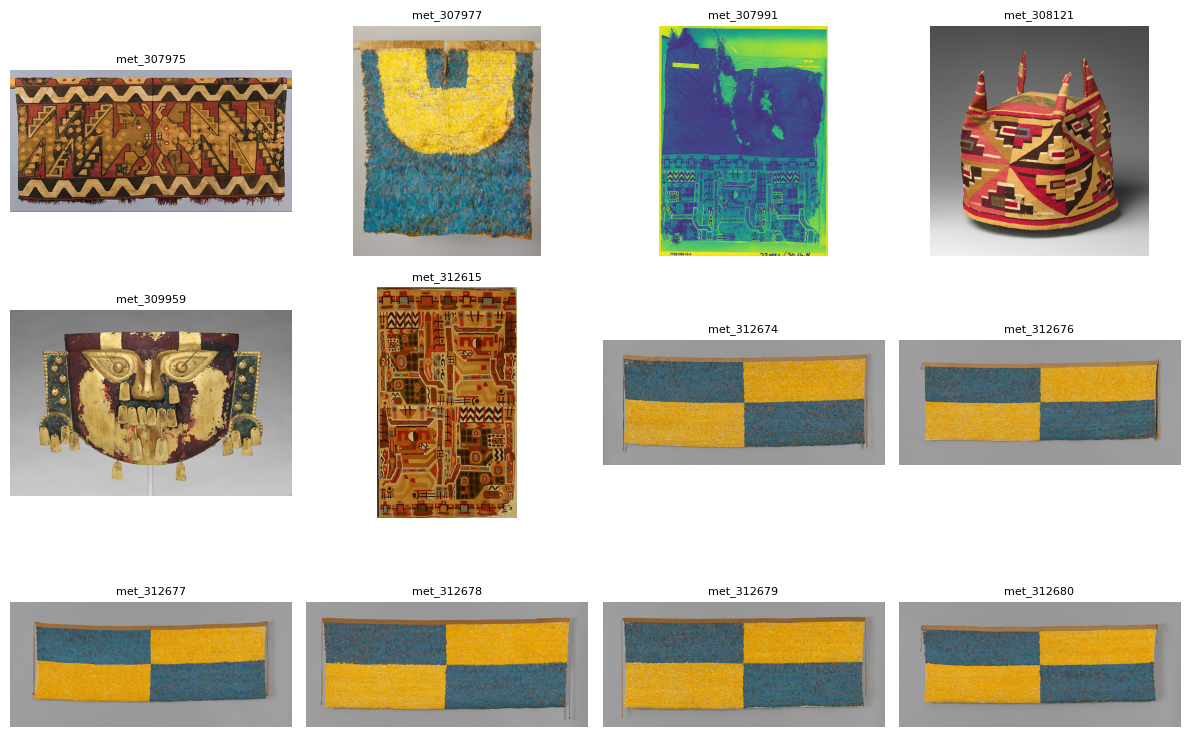

In [9]:
n = min(12, len(image_paths))

plt.figure(figsize=(12, 8))

for i, image_path in enumerate(image_paths[:n]):
    img = Image.open(image_path)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_path.stem, fontsize=8)

plt.tight_layout()
plt.show()